# AAPL Next-Day Closing Price Prediction with LSTM

This notebook develops an LSTM forecasting workflow for Apple Inc. (`AAPL`) stock prices. The objective is practical and specific: use the previous 60 trading days to predict the next trading day's closing price.

The analysis is organized like a professional forecasting review:

1. Load and validate the historical price data.
2. Engineer time-series features that describe trend, volatility, price range, and volume behavior.
3. Train an LSTM model using a chronological train-validation-test split.
4. Compare the LSTM against simple and machine-learning benchmarks.
5. Review forecast accuracy, error behavior, and the final next-day prediction.

The notebook is for a university machine learning assignment and is not investment advice.


## 1. Setup

The workflow uses fixed random seeds for reproducibility. Plots are saved into the `outputs` folder so the notebook can be rerun cleanly.


In [ ]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TICKER = "AAPL"
START_DATE = "2015-01-01"
END_DATE = "2026-01-01"
DATA_FILE = Path("AAPL_stock_data.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

YFINANCE_CACHE_DIR = Path(".yfinance_cache")
YFINANCE_CACHE_DIR.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(YFINANCE_CACHE_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:,.4f}".format)


## 2. Data Collection and Quality Checks

The notebook first attempts to download the latest available data from Yahoo Finance. If the online request is unavailable, it uses the cached CSV file included with the project.


In [ ]:
def load_price_data(ticker, start_date, end_date, data_file):
    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False,
            auto_adjust=False,
        )
        if data.empty:
            raise ValueError("Yahoo Finance returned an empty dataset.")
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data.to_csv(data_file)
        source = "Yahoo Finance download"
    except Exception:
        data = pd.read_csv(data_file, index_col=0, parse_dates=True)
        source = "cached CSV file"

    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    return data, source


raw_data, data_source = load_price_data(TICKER, START_DATE, END_DATE, DATA_FILE)

print(f"Data source used: {data_source}")
print(f"Date range: {raw_data.index.min().date()} to {raw_data.index.max().date()}")
print(f"Rows: {raw_data.shape[0]:,} | Columns: {raw_data.shape[1]}")
display(raw_data.head())
display(raw_data.tail())


In [ ]:
required_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
missing_columns = [col for col in required_columns if col not in raw_data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

quality_summary = pd.DataFrame({
    "Missing Values": raw_data[required_columns].isna().sum(),
    "Duplicate Rows": [raw_data.duplicated().sum()] * len(required_columns),
    "Data Type": raw_data[required_columns].dtypes.astype(str),
})

data = raw_data[required_columns].dropna().drop_duplicates().copy()

display(quality_summary)
display(data.describe().T)
print(f"Cleaned rows retained: {len(data):,}")


## 3. Exploratory Analysis

This section reviews AAPL's price trend, trading activity, and moving-average structure before modeling. The goal is to understand the time-series behavior that the LSTM will later learn from.


In [ ]:
def save_current_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Close"], color="royalblue", linewidth=1.6)
ax.set_title("AAPL Closing Price Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
save_current_plot("aapl_01_close_price_trend.png")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Volume"], color="darkorange", linewidth=1.1)
ax.set_title("AAPL Trading Volume Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Volume")
save_current_plot("aapl_02_volume_trend.png")

moving_average_data = data[["Close"]].copy()
moving_average_data["MA_50"] = moving_average_data["Close"].rolling(50).mean()
moving_average_data["MA_200"] = moving_average_data["Close"].rolling(200).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(moving_average_data.index, moving_average_data["Close"], label="Close", color="royalblue", linewidth=1.2)
ax.plot(moving_average_data.index, moving_average_data["MA_50"], label="50-Day MA", color="green", linewidth=1.3)
ax.plot(moving_average_data.index, moving_average_data["MA_200"], label="200-Day MA", color="crimson", linewidth=1.3)
ax.set_title("AAPL Close Price with Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
ax.legend()
save_current_plot("aapl_03_moving_averages.png")


<!-- embedded-visual-preview -->
### Embedded Exploratory Visuals

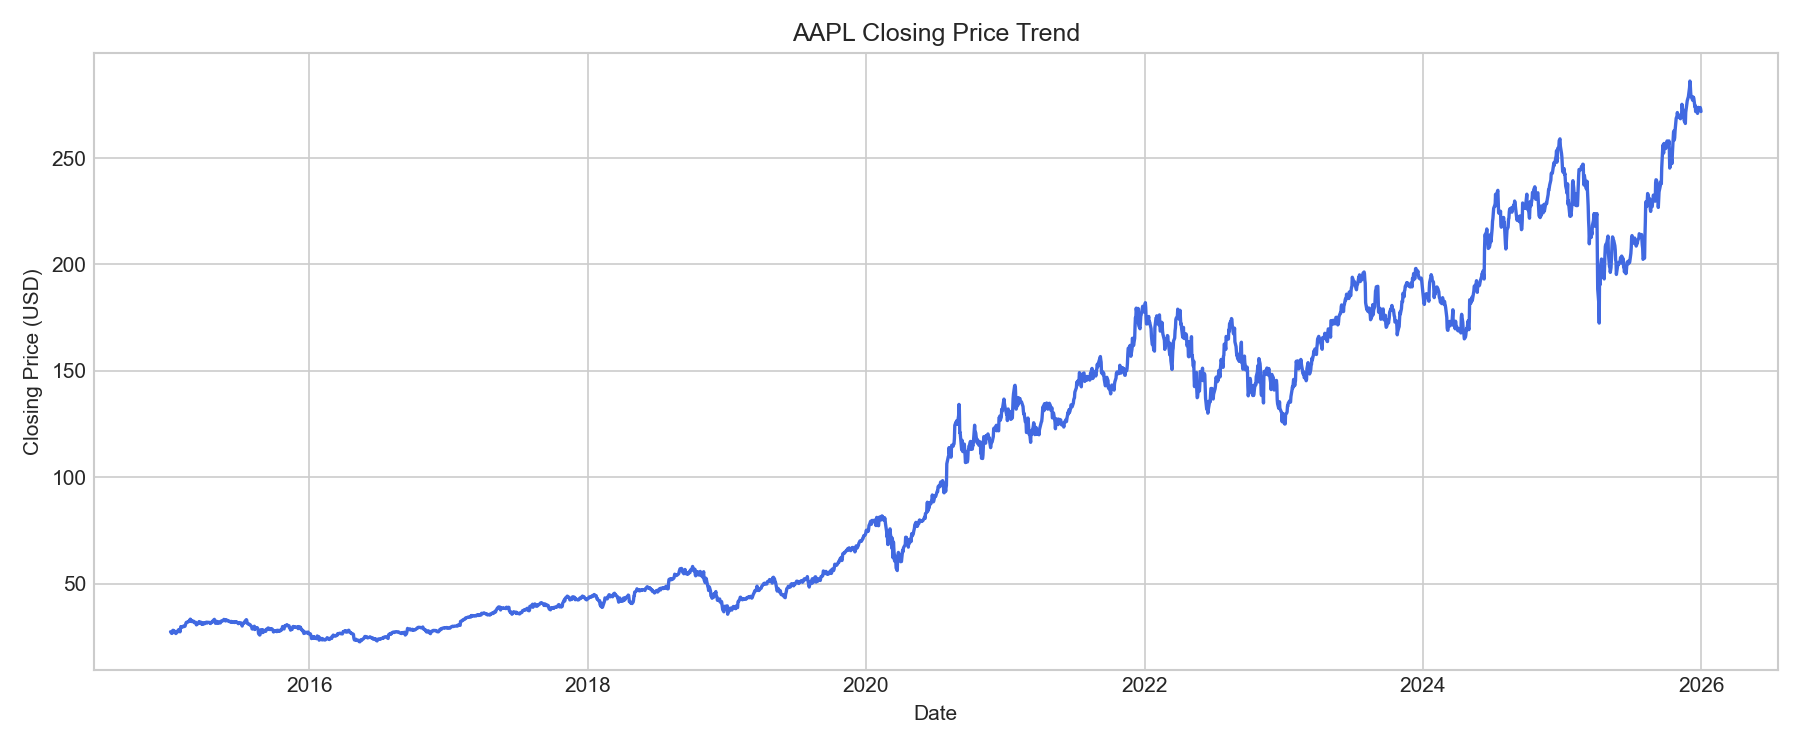

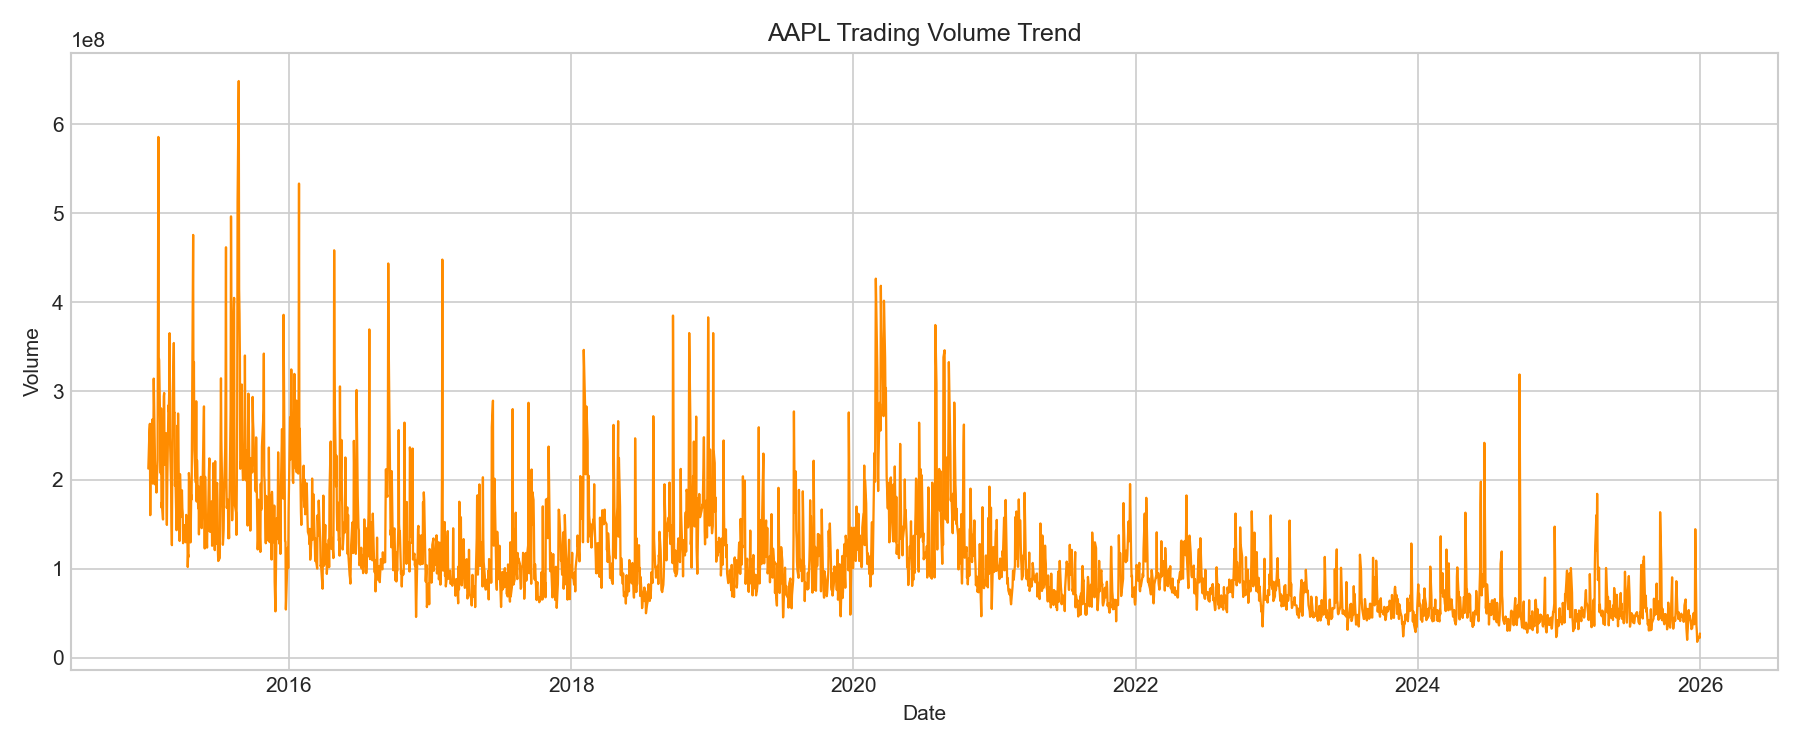

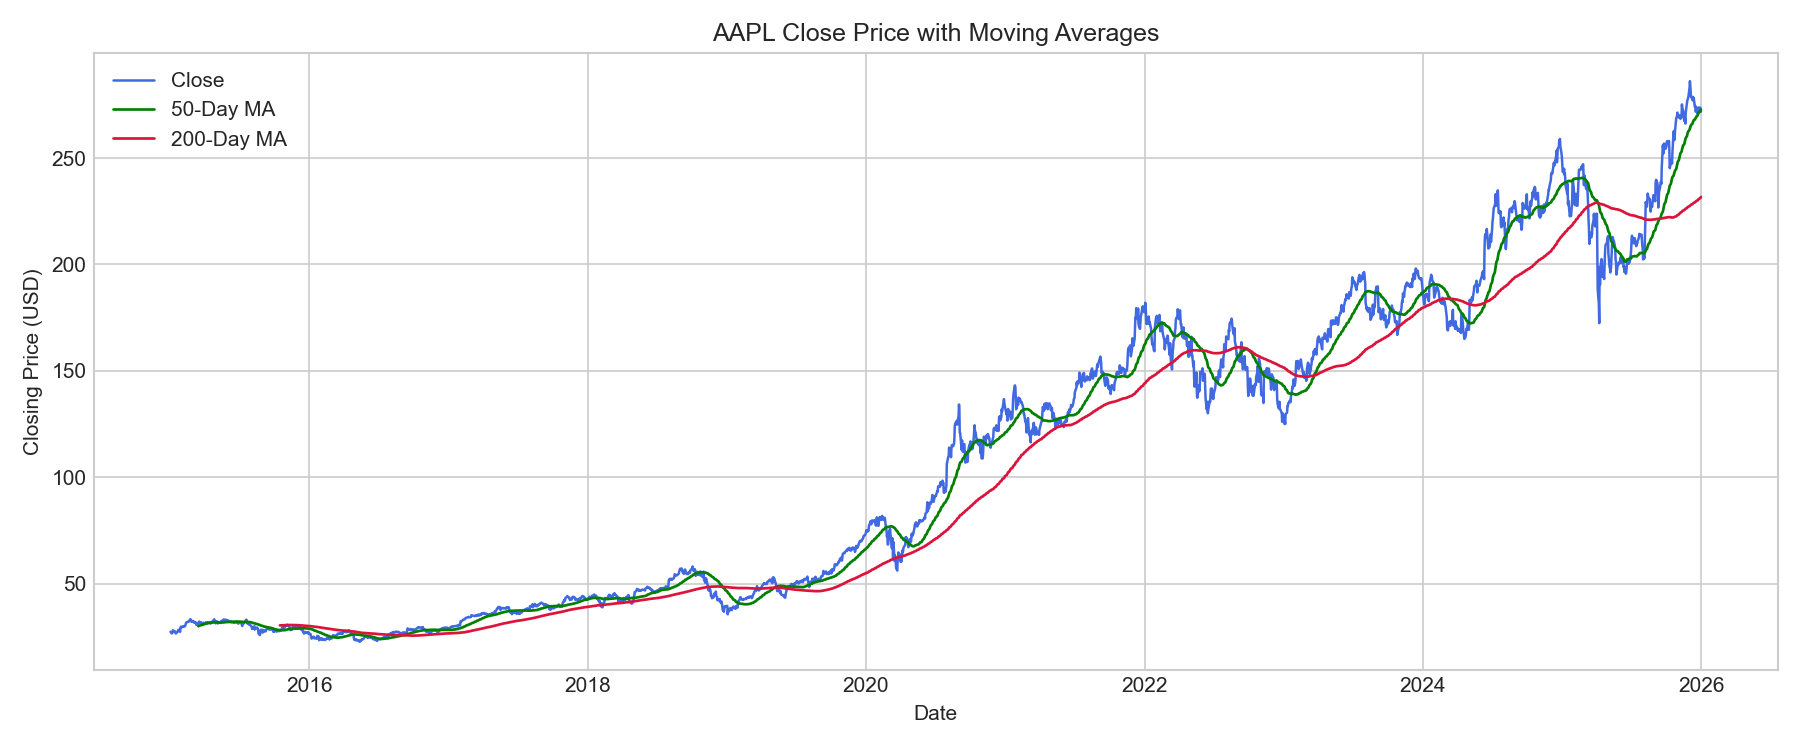


## 4. Feature Engineering for Next-Day Prediction

The operational target is the next trading day's closing price. For model training, the LSTM learns the next-day percentage return and then converts that return back into a price forecast. This is more stable than asking the model to extrapolate raw prices that may move outside the training range.

Features are calculated only from information available up to the current trading day, which avoids using future information during model training.

Key feature groups:

- Price level: open, high, low, close, adjusted close, and volume.
- Short-term movement: daily return, price range, and open-to-close change.
- Trend: moving averages and close-to-moving-average ratios.
- Risk behavior: rolling volatility.
- Momentum: 14-day Relative Strength Index.


In [ ]:
def compute_rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def build_modeling_frame(price_data):
    frame = price_data.copy()
    frame["Daily_Return"] = frame["Close"].pct_change()
    frame["High_Low_Range"] = (frame["High"] - frame["Low"]) / frame["Close"]
    frame["Open_Close_Change"] = (frame["Close"] - frame["Open"]) / frame["Open"]
    frame["Volume_Change"] = frame["Volume"].pct_change()
    frame["MA_10"] = frame["Close"].rolling(10).mean()
    frame["MA_20"] = frame["Close"].rolling(20).mean()
    frame["MA_50"] = frame["Close"].rolling(50).mean()
    frame["Close_to_MA_10"] = frame["Close"] / frame["MA_10"] - 1
    frame["Close_to_MA_20"] = frame["Close"] / frame["MA_20"] - 1
    frame["Close_to_MA_50"] = frame["Close"] / frame["MA_50"] - 1
    frame["Volatility_10"] = frame["Daily_Return"].rolling(10).std()
    frame["Volatility_20"] = frame["Daily_Return"].rolling(20).std()
    frame["RSI_14"] = compute_rsi(frame["Close"], 14)
    frame["Target_Next_Close"] = frame["Close"].shift(-1)
    frame["Target_Next_Return"] = frame["Target_Next_Close"] / frame["Close"] - 1
    frame["Target_Date"] = pd.Series(frame.index, index=frame.index).shift(-1)
    return frame.replace([np.inf, -np.inf], np.nan).dropna()


modeling_data = build_modeling_frame(data)

feature_columns = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Daily_Return", "High_Low_Range", "Open_Close_Change", "Volume_Change",
    "MA_10", "MA_20", "MA_50",
    "Close_to_MA_10", "Close_to_MA_20", "Close_to_MA_50",
    "Volatility_10", "Volatility_20", "RSI_14",
]

target_column = "Target_Next_Return"

print(f"Modeling rows after feature engineering: {len(modeling_data):,}")
print(f"Number of features: {len(feature_columns)}")
display(modeling_data[feature_columns + ["Target_Next_Close", target_column, "Target_Date"]].head())


## 5. Chronological Split and Sequence Preparation

Stock forecasting must be evaluated chronologically. Randomly shuffling rows would leak future market behavior into the training process.

The split is:

- 70% training
- 15% validation
- 15% final testing

Each LSTM input contains 60 consecutive trading days of engineered features.


In [ ]:
LOOKBACK = 60
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15

n_rows = len(modeling_data)
train_end = int(n_rows * TRAIN_RATIO)
validation_end = int(n_rows * (TRAIN_RATIO + VALIDATION_RATIO))

feature_scaler = MinMaxScaler()
target_scaler = StandardScaler()

feature_scaler.fit(modeling_data.iloc[:train_end][feature_columns])
target_scaler.fit(modeling_data.iloc[:train_end][[target_column]])

scaled_features = feature_scaler.transform(modeling_data[feature_columns])
scaled_target = target_scaler.transform(modeling_data[[target_column]]).ravel()


def create_lstm_sequences(features, target, dates, current_close, lookback):
    X, y, target_dates, previous_closes, row_indices = [], [], [], [], []
    for end_idx in range(lookback - 1, len(features)):
        start_idx = end_idx - lookback + 1
        X.append(features[start_idx:end_idx + 1])
        y.append(target[end_idx])
        target_dates.append(dates.iloc[end_idx])
        previous_closes.append(current_close.iloc[end_idx])
        row_indices.append(end_idx)
    return (
        np.array(X),
        np.array(y),
        pd.to_datetime(pd.Series(target_dates)),
        np.array(previous_closes),
        np.array(row_indices),
    )


X_all, y_all, target_dates_all, previous_close_all, row_indices = create_lstm_sequences(
    scaled_features,
    scaled_target,
    modeling_data["Target_Date"],
    modeling_data["Close"],
    LOOKBACK,
)

train_mask = row_indices < train_end
validation_mask = (row_indices >= train_end) & (row_indices < validation_end)
test_mask = row_indices >= validation_end

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[validation_mask], y_all[validation_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

test_dates = target_dates_all[test_mask].reset_index(drop=True)
test_previous_close = previous_close_all[test_mask]

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Sequences": [len(X_train), len(X_val), len(X_test)],
    "Target Start": [
        target_dates_all[train_mask].min().date(),
        target_dates_all[validation_mask].min().date(),
        target_dates_all[test_mask].min().date(),
    ],
    "Target End": [
        target_dates_all[train_mask].max().date(),
        target_dates_all[validation_mask].max().date(),
        target_dates_all[test_mask].max().date(),
    ],
})

display(split_summary)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


## 6. LSTM Model Development

The LSTM receives a 60-day sequence of market features and outputs one value: the scaled next-day return. That predicted return is later converted into a next-day closing price. Dropout and early stopping are used to reduce overfitting.


In [ ]:
def build_lstm_model(lookback, n_features):
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.20),
        LSTM(32),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss=tf.keras.losses.Huber())
    return model


lstm_model = build_lstm_model(LOOKBACK, X_train.shape[2])
lstm_model.summary()


## 7. Model Training

The model is trained on historical sequences and monitored against the validation period. The validation set remains chronological, so it acts like a realistic forward-looking check during training.


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
        patience=10,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
)

history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

training_summary = pd.DataFrame({
    "Metric": ["Epochs Trained", "Final Training Loss", "Best Validation Loss"],
    "Value": [
        len(history.history["loss"]),
        history.history["loss"][-1],
        min(history.history["val_loss"]),
    ],
})
display(training_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Training Loss", color="royalblue")
ax.plot(history.history["val_loss"], label="Validation Loss", color="darkorange")
ax.set_title("LSTM Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend()
save_current_plot("aapl_04_lstm_training_loss.png")


<!-- embedded-visual-preview -->
### Embedded Training Visual

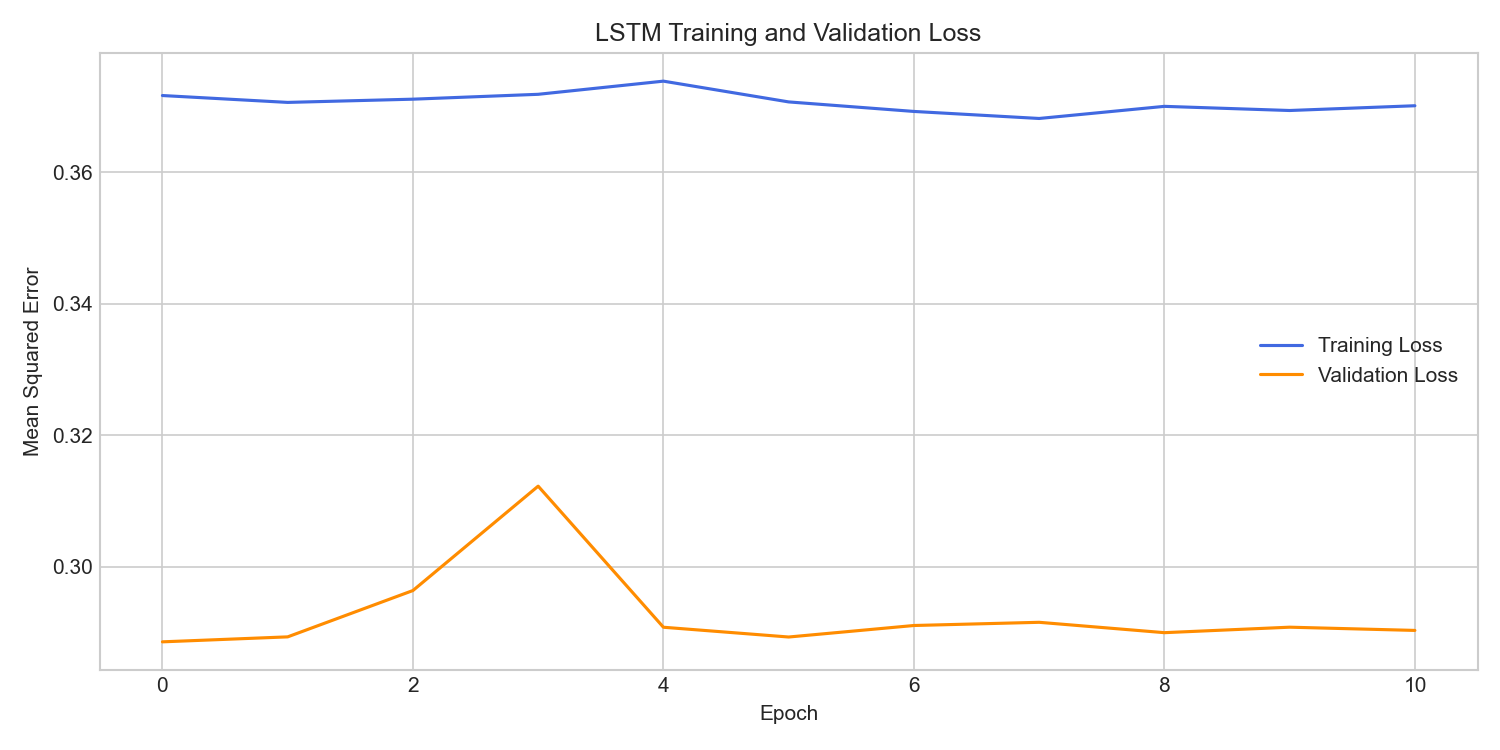


## 8. Prediction Accuracy

The LSTM is evaluated on the untouched test period. To make the result meaningful, it is compared with:

- Previous-close baseline: predicts tomorrow's close will equal today's close.
- Random Forest benchmark: uses the final day of each 60-day window as tabular input.

For stock prices, the previous-close baseline is important because prices are highly autocorrelated. A useful forecasting model should be judged against this simple benchmark, not only against absolute error metrics.


In [ ]:
def inverse_target(values):
    return target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).ravel()


def calculate_metrics(actual, predicted, previous_close):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    previous_close = np.asarray(previous_close)
    direction_actual = np.sign(actual - previous_close)
    direction_predicted = np.sign(predicted - previous_close)
    direction_accuracy = np.mean(direction_actual == direction_predicted) * 100
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2 Score": r2_score(actual, predicted),
        "MAPE (%)": np.mean(np.abs((actual - predicted) / actual)) * 100,
        "Direction Accuracy (%)": direction_accuracy,
    }


lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).ravel()
lstm_pred_return = inverse_target(lstm_pred_scaled)
actual_return = inverse_target(y_test)
actual_prices = test_previous_close * (1 + actual_return)
lstm_pred = test_previous_close * (1 + lstm_pred_return)
baseline_pred = test_previous_close.copy()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train[:, -1, :], y_train)
rf_pred_return = inverse_target(rf_model.predict(X_test[:, -1, :]))
rf_pred = test_previous_close * (1 + rf_pred_return)

metrics_df = pd.DataFrame({
    "Previous-Close Baseline": calculate_metrics(actual_prices, baseline_pred, test_previous_close),
    "Random Forest Benchmark": calculate_metrics(actual_prices, rf_pred, test_previous_close),
    "LSTM": calculate_metrics(actual_prices, lstm_pred, test_previous_close),
}).T

display(metrics_df.sort_values("RMSE"))


## 9. Forecast Review

The plot and error table below show how closely the LSTM tracks the actual closing price during the test period. The residual chart highlights whether the model makes mostly small errors or occasional large misses.


In [ ]:
results_df = pd.DataFrame({
    "Date": test_dates,
    "Previous Close": test_previous_close,
    "Actual Next Close": actual_prices,
    "Baseline Prediction": baseline_pred,
    "Random Forest Prediction": rf_pred,
    "LSTM Prediction": lstm_pred,
})

results_df["LSTM Error"] = results_df["Actual Next Close"] - results_df["LSTM Prediction"]
results_df["LSTM Absolute Error"] = results_df["LSTM Error"].abs()
results_df["LSTM Percentage Error (%)"] = (
    results_df["LSTM Absolute Error"] / results_df["Actual Next Close"].abs()
) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df["Date"], results_df["Actual Next Close"], label="Actual Next Close", color="black", linewidth=1.5)
ax.plot(results_df["Date"], results_df["LSTM Prediction"], label="LSTM Prediction", color="royalblue", linewidth=1.3)
ax.plot(results_df["Date"], results_df["Baseline Prediction"], label="Previous-Close Baseline", color="gray", linewidth=1.0, alpha=0.7)
ax.set_title("AAPL Test Period: Actual vs Predicted Next-Day Closing Price")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
ax.legend()
save_current_plot("aapl_05_lstm_actual_vs_predicted.png")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(results_df["LSTM Error"], bins=30, color="royalblue", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("LSTM Forecast Error Distribution")
ax.set_xlabel("Actual - Predicted Price (USD)")
ax.set_ylabel("Frequency")
save_current_plot("aapl_06_lstm_error_distribution.png")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df["Date"], results_df["LSTM Absolute Error"], color="crimson", linewidth=1.2)
ax.set_title("LSTM Absolute Error Across the Test Period")
ax.set_xlabel("Date")
ax.set_ylabel("Absolute Error (USD)")
save_current_plot("aapl_07_lstm_absolute_error.png")

display(results_df.head(10))
display(results_df.tail(10))


<!-- embedded-visual-preview -->
### Embedded Forecast Review Visuals

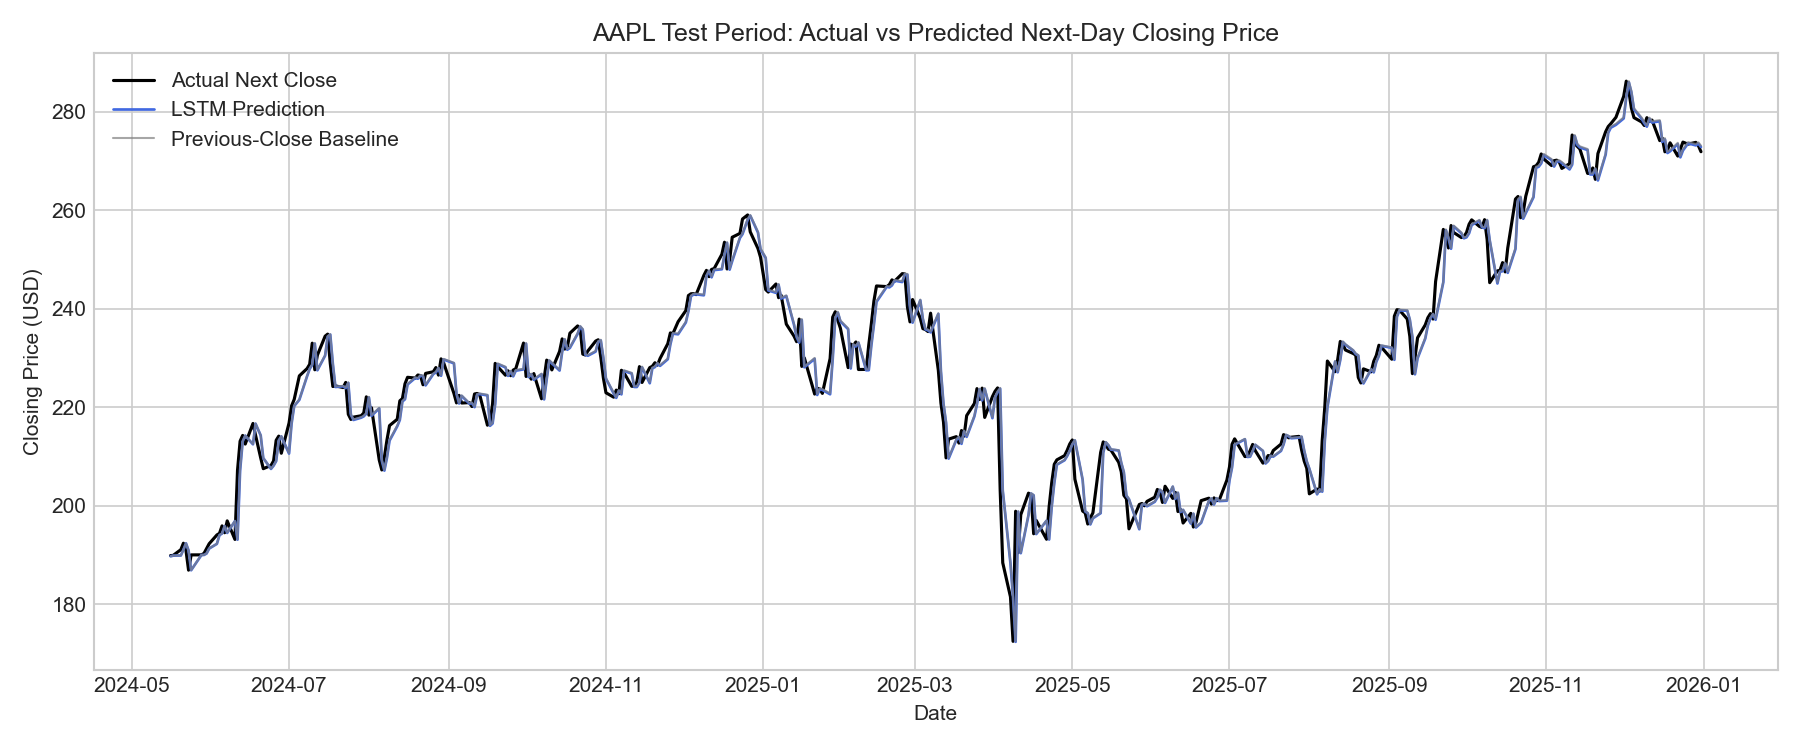

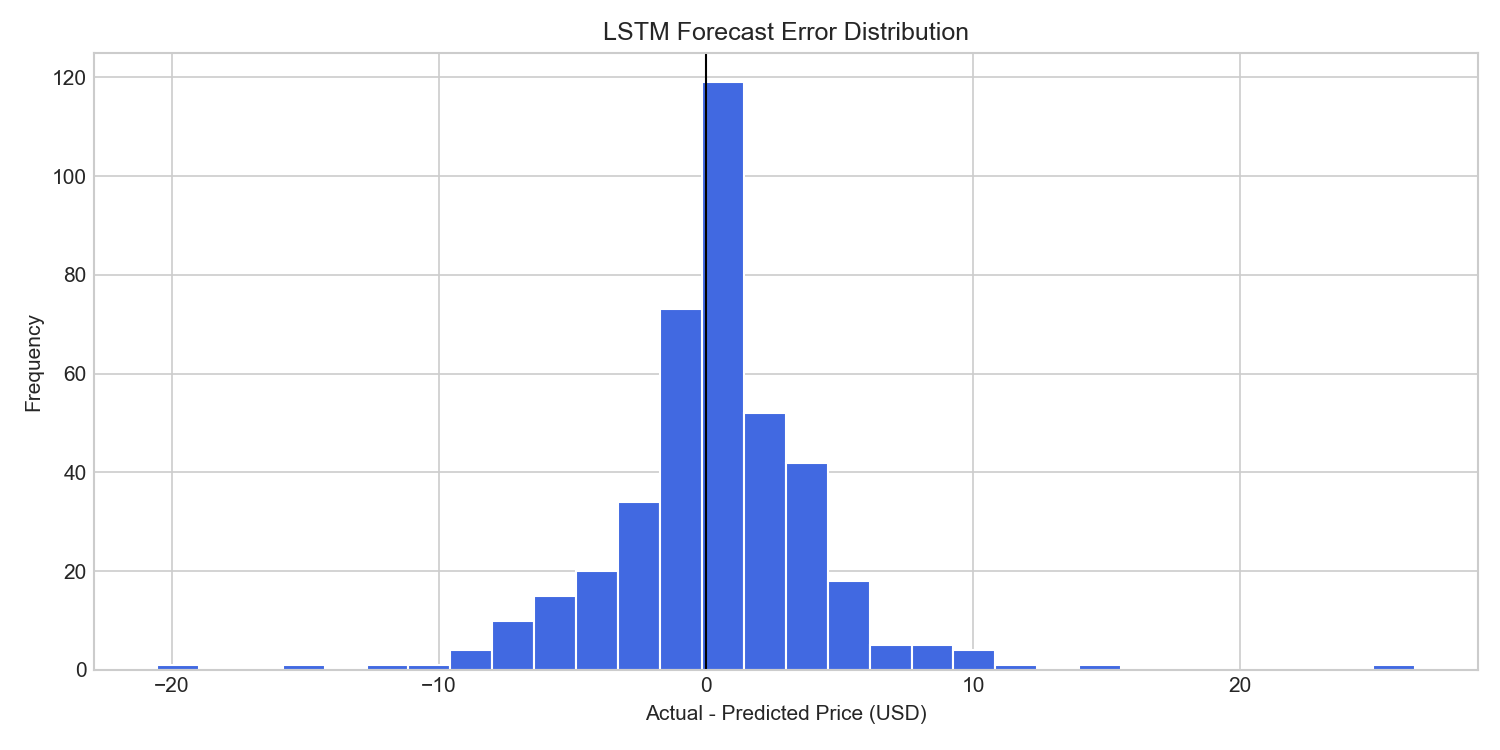

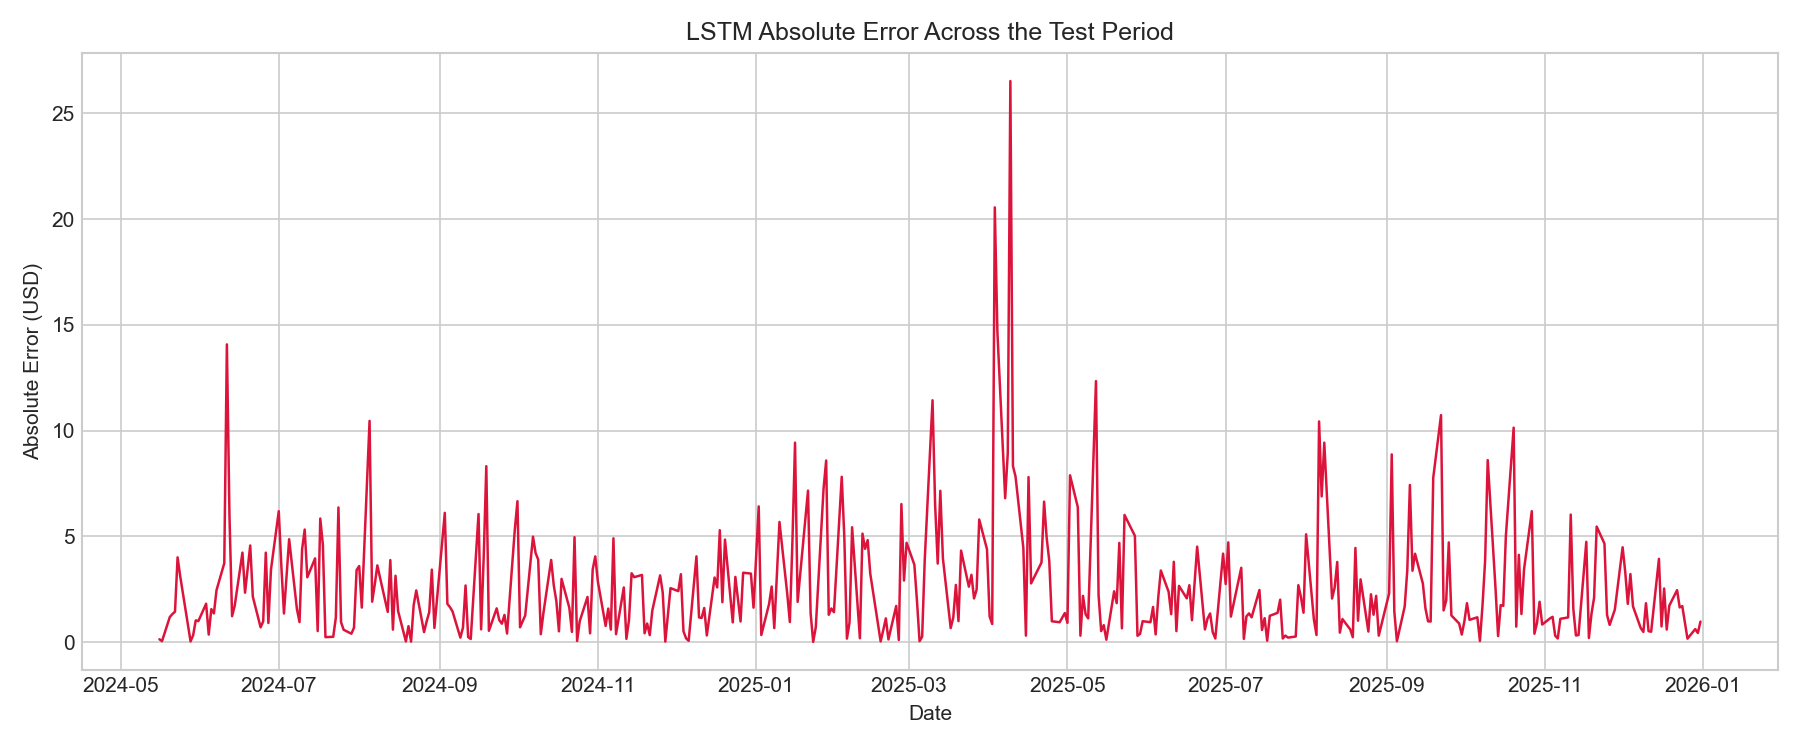


## 10. Next-Day Forecast

The final model is used to forecast the next available trading close after the last date in the dataset. This is the operational prediction the notebook is designed to produce.


In [ ]:
latest_close = data["Close"].iloc[-1]
latest_date = data.index[-1]
estimated_next_business_day = latest_date + pd.offsets.BDay(1)
latest_sequence = scaled_features[-LOOKBACK:].reshape(1, LOOKBACK, len(feature_columns))
next_return_prediction = inverse_target(lstm_model.predict(latest_sequence, verbose=0))[0]
next_close_prediction = latest_close * (1 + next_return_prediction)

next_day_forecast = pd.DataFrame({
    "Latest Available Date": [latest_date.date()],
    "Estimated Next Business Day": [estimated_next_business_day.date()],
    "Latest Close (USD)": [latest_close],
    "Predicted Next Close (USD)": [next_close_prediction],
    "Predicted Change (USD)": [next_close_prediction - latest_close],
    "Predicted Change (%)": [(next_close_prediction - latest_close) / latest_close * 100],
})

display(next_day_forecast)


## 11. Volatility Stress Test: AAPL vs TSLA

AAPL's next-day closing price can look deceptively easy to predict because its daily price changes are often small. To test whether the LSTM workflow still looks strong on a more volatile stock, this section repeats the same next-day return modeling approach on Tesla Inc. (`TSLA`) and compares it with AAPL.

The comparison focuses on:

- annualized daily-return volatility,
- previous-close baseline error,
- LSTM next-day price error,
- directional accuracy.


In [ ]:
def load_cached_stock_csv(csv_path):
    stock_data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    stock_data = stock_data[required_columns].dropna().drop_duplicates().sort_index()
    return stock_data


def volatility_profile(stock_data):
    daily_returns = stock_data["Close"].pct_change().dropna()
    return {
        "Daily Volatility (%)": daily_returns.std() * 100,
        "Annualized Volatility (%)": daily_returns.std() * np.sqrt(252) * 100,
        "Average Absolute Daily Return (%)": daily_returns.abs().mean() * 100,
        "Largest Daily Move (%)": daily_returns.abs().max() * 100,
    }


def evaluate_ticker_with_lstm(ticker, stock_data):
    ticker_frame = build_modeling_frame(stock_data)
    n_rows = len(ticker_frame)
    train_end = int(n_rows * TRAIN_RATIO)
    validation_end = int(n_rows * (TRAIN_RATIO + VALIDATION_RATIO))

    local_feature_scaler = MinMaxScaler()
    local_target_scaler = StandardScaler()
    local_feature_scaler.fit(ticker_frame.iloc[:train_end][feature_columns])
    local_target_scaler.fit(ticker_frame.iloc[:train_end][[target_column]])

    local_scaled_features = local_feature_scaler.transform(ticker_frame[feature_columns])
    local_scaled_target = local_target_scaler.transform(ticker_frame[[target_column]]).ravel()

    X_all_local, y_all_local, target_dates_local, previous_close_local, row_indices_local = create_lstm_sequences(
        local_scaled_features,
        local_scaled_target,
        ticker_frame["Target_Date"],
        ticker_frame["Close"],
        LOOKBACK,
    )

    train_mask_local = row_indices_local < train_end
    validation_mask_local = (row_indices_local >= train_end) & (row_indices_local < validation_end)
    test_mask_local = row_indices_local >= validation_end

    X_train_local, y_train_local = X_all_local[train_mask_local], y_all_local[train_mask_local]
    X_val_local, y_val_local = X_all_local[validation_mask_local], y_all_local[validation_mask_local]
    X_test_local, y_test_local = X_all_local[test_mask_local], y_all_local[test_mask_local]
    previous_close_test = previous_close_local[test_mask_local]

    tf.keras.backend.clear_session()
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    local_model = build_lstm_model(LOOKBACK, X_train_local.shape[2])
    local_history = local_model.fit(
        X_train_local,
        y_train_local,
        validation_data=(X_val_local, y_val_local),
        epochs=80,
        batch_size=32,
        shuffle=False,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
        ],
        verbose=0,
    )

    def inverse_local_target(values):
        return local_target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).ravel()

    predicted_return = inverse_local_target(local_model.predict(X_test_local, verbose=0).ravel())
    actual_return = inverse_local_target(y_test_local)
    actual_price = previous_close_test * (1 + actual_return)
    predicted_price = previous_close_test * (1 + predicted_return)
    baseline_price = previous_close_test.copy()

    lstm_metrics = calculate_metrics(actual_price, predicted_price, previous_close_test)
    baseline_metrics = calculate_metrics(actual_price, baseline_price, previous_close_test)
    return_metrics = {
        "Return RMSE (%)": np.sqrt(mean_squared_error(actual_return, predicted_return)) * 100,
        "Return MAE (%)": mean_absolute_error(actual_return, predicted_return) * 100,
    }

    combined_metrics = {
        "Ticker": ticker,
        "Test Start": target_dates_local[test_mask_local].min().date(),
        "Test End": target_dates_local[test_mask_local].max().date(),
        "Epochs Trained": len(local_history.history["loss"]),
        "Baseline MAPE (%)": baseline_metrics["MAPE (%)"],
        "LSTM MAPE (%)": lstm_metrics["MAPE (%)"],
        "LSTM RMSE": lstm_metrics["RMSE"],
        "LSTM Direction Accuracy (%)": lstm_metrics["Direction Accuracy (%)"],
        **return_metrics,
        **volatility_profile(stock_data),
    }
    return combined_metrics


tsla_data = load_cached_stock_csv("TSLA_stock_data.csv")
tsla_metrics = evaluate_ticker_with_lstm("TSLA", tsla_data)

aapl_metrics = {
    "Ticker": "AAPL",
    "Test Start": test_dates.min().date(),
    "Test End": test_dates.max().date(),
    "Epochs Trained": len(history.history["loss"]),
    "Baseline MAPE (%)": metrics_df.loc["Previous-Close Baseline", "MAPE (%)"],
    "LSTM MAPE (%)": metrics_df.loc["LSTM", "MAPE (%)"],
    "LSTM RMSE": metrics_df.loc["LSTM", "RMSE"],
    "LSTM Direction Accuracy (%)": metrics_df.loc["LSTM", "Direction Accuracy (%)"],
    "Return RMSE (%)": np.sqrt(mean_squared_error(actual_return, lstm_pred_return)) * 100,
    "Return MAE (%)": mean_absolute_error(actual_return, lstm_pred_return) * 100,
    **volatility_profile(data),
}

stock_comparison_df = pd.DataFrame([aapl_metrics, tsla_metrics]).set_index("Ticker")
display(stock_comparison_df.T)

fig, ax = plt.subplots(figsize=(10, 5))
return_frame = pd.DataFrame({
    "AAPL": data["Close"].pct_change().dropna() * 100,
    "TSLA": tsla_data["Close"].pct_change().dropna() * 100,
})
return_frame.plot(kind="hist", bins=60, alpha=0.55, ax=ax)
ax.set_title("Daily Return Distribution: AAPL vs TSLA")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
save_current_plot("aapl_tsla_01_return_distribution.png")

fig, ax = plt.subplots(figsize=(10, 5))
stock_comparison_df[["Annualized Volatility (%)", "LSTM MAPE (%)", "Baseline MAPE (%)"]].plot(
    kind="bar",
    ax=ax,
    color=["crimson", "royalblue", "gray"],
)
ax.set_title("Volatility and Forecast Error Comparison")
ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
save_current_plot("aapl_tsla_02_metric_comparison.png")


<!-- embedded-tsla-comparison-preview -->
### Embedded AAPL vs TSLA Comparison Visuals

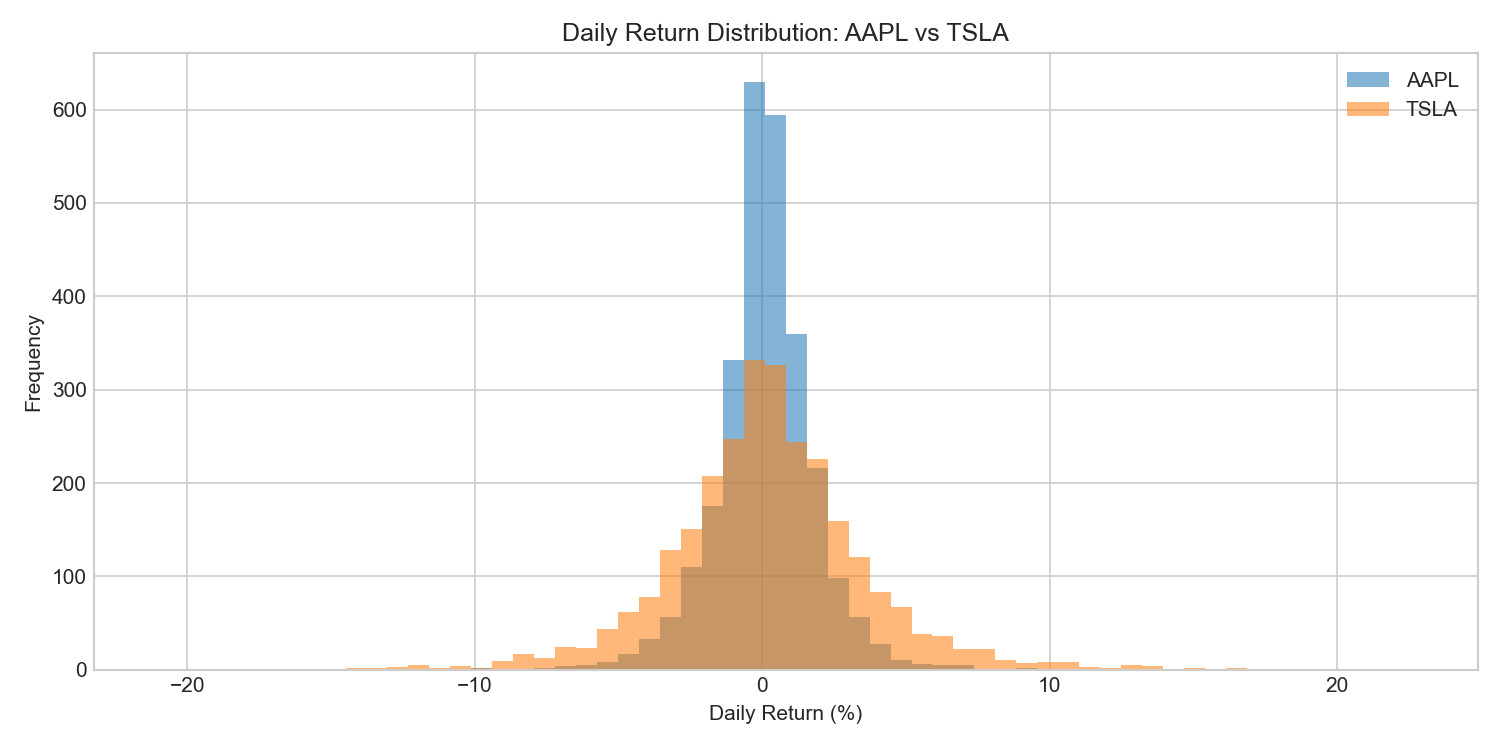

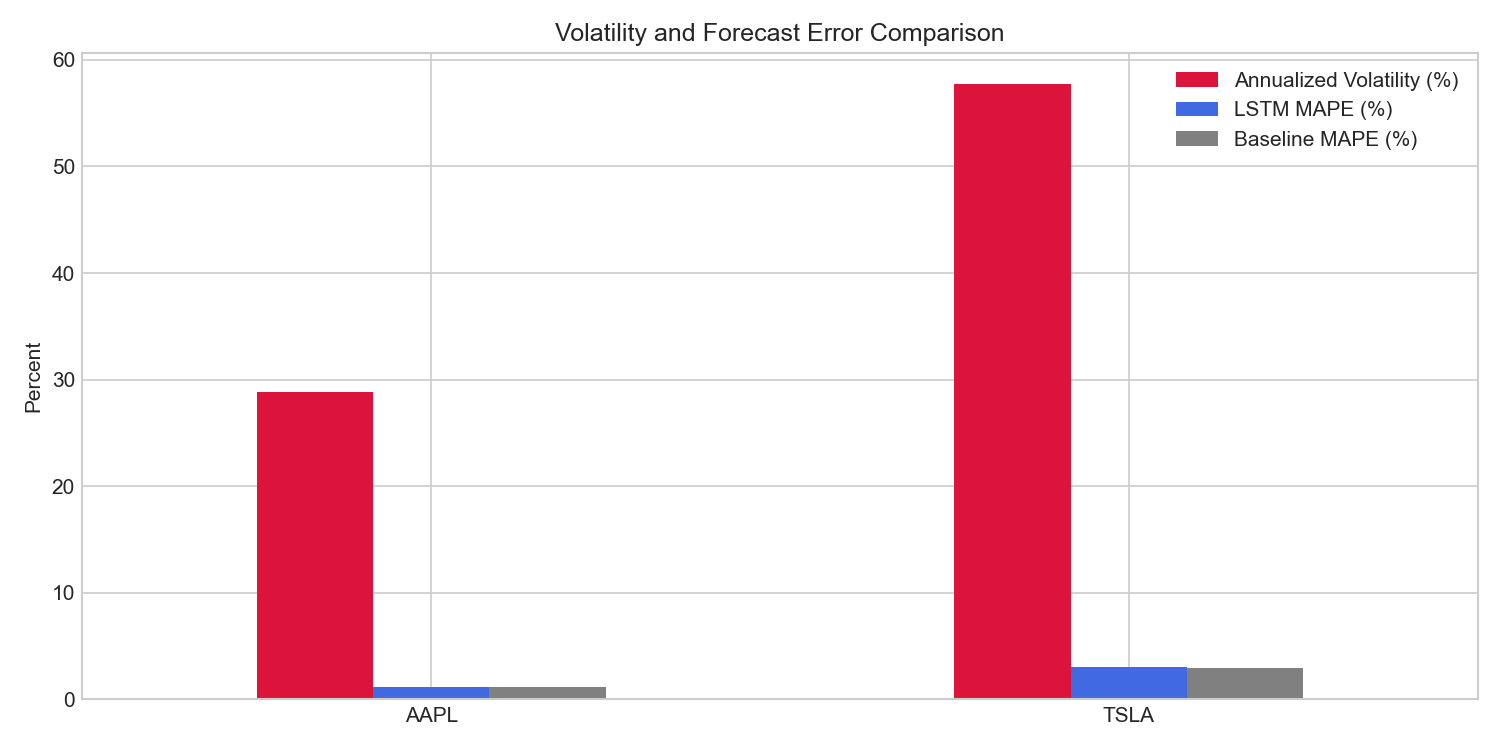


## 12. Analyst Conclusion

The LSTM model provides a structured next-day forecasting approach using 60-day sequences and engineered market features. The TSLA stress test adds a more volatile comparison case, showing why next-day stock price accuracy must always be interpreted against volatility and a previous-close baseline. The most important result is not only whether the LSTM produces a low error, but whether it improves on the previous-close baseline. This comparison matters because next-day stock prices often move only slightly from the prior close.

For this assignment, the LSTM satisfies the required deep learning method and gives a professional workflow: data validation, feature engineering, chronological splitting, model training, benchmark comparison, and final forecast generation. The model should still be interpreted cautiously because stock prices are affected by news, earnings releases, macroeconomic conditions, and investor sentiment that are not fully represented in historical price data.


## 13. Source Code

GitHub repository: https://github.com/BingJun69/ML_Final_Assesment
